## **Introduzione**

La seguente analisi è stata effettuata utilizzando un dataset che raccoglie i dati sui crimini registrati nella città di **Baltimora (Maryland, USA)** tra gli anni 2010 e 2017.
Il dataset contiene informazioni dettagliate su ogni evento criminale, tra cui **data, ora, tipologia di reato, localizzazione geografica, distretto di polizia e coordinate GPS**, coprendo un ampio periodo temporale.

L'obiettivo dell'analisi è quello di effettuare una classificazione del tipo di arma utilizzata per il crimine, partendo dalle informazioni contenute nel dataset.

Per l'analisi verranno utilizzate librerie Python come **pandas, matplotlib, seaborn, statsmodels, numpy, imbdlearn e sklearn**, che consentiranno di effettuare una **pulizia accurata dei dati, un'analisi esplorativa (EDA) e la modellazione predittiva**.

**N.B.**: Per questioni di compatibilità con le versioni delle librerie, si consiglia di utilizzare la versione **3.12.4** di Python.

In [33]:
# Installazione dei pacchetti necessari
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier 
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN

### **Import del dataset**

Si inizia l'analisi importando il dataset in formato `.csv`, disponibile al seguente link ufficiale:
🔗 [City of Baltimore Crime Data](https://data.world/data-society/city-of-baltimore-crime-data)

Per avere una visualizzazione piu' dettagliata del dataset, si consiglia di visionare il file `timeseries.ipynb`, che contiene un'analisi piu' dettagliata delle feature del dataset.

### **Considerazioni preliminari**
Una prima analisi esplorativa (non mostrata qui) ha evidenziato la presenza di valori mancanti, colonne ridondanti e formati non uniformi (in particolare date, orari e coordinate geografiche).

1. **Gestione dei valori mancanti**
   - Le colonne `Location`, `Inside/Outside`, `Weapon`, `District` e    `Neighborhood` presentano una certa quantità di valori nulli.
   - Si sostituiranno i valori con una categoria "Unknown".

2. **Creazione della colonna temporale unificata**
   - Le colonne `CrimeDate` e `CrimeTime` saranno unite in un'unica colonna `Datetime`.

3. **Estrazione di feature temporali**
   - Dalla colonna `DateTime` sono state ricavate variabili derivate:
      - `Year`, `Month`, `Day`, `Hour` e `DayOfWeek`, che consentono analisi più dettagliate sulla distribuzione temporale dei crimini.

4. **Pulizia delle informazioni geografiche**
   - Le colonne `Latitude` e `Longitude` sono state estratte dalla colonna `Location 1`.
   - La colonna `Location 1` ha un formato non uniforme, quindi viene eliminata.

5. **Codifica delle variabili categoriche**
   - Le colonne `CrimeCode`, `Location`, `Description`, `Weapon`, `District`, `Neighborhood` e `DayOfWeek` sono state codificate utilizzando Label Encoding.
   - La variabile `Inside/Outside` è stata mappata manualmente:
      - `I` -> 1 (Interno)
      - `O` -> 0 (Esterno)
      - Valori sconosciuti -> -1

6. **Eliminazione delle colonne originali e salvataggio del dataset**
   - Dopo l'encoding, le colonne categoriche e altre informazioni ridondanti sono state eliminate.
   - Il risultato è un dataset **numerico, privo di valori mancanti** e **codificato**, pronto per essere utilizzato per l'analisi predittiva.

In [35]:
file_path = 'CrimeData.csv'
crime_data = pd.read_csv(file_path)

# ==========================
### Gestione dei valori mancanti
# ==========================
cols_to_fill = ['Location', 'Inside/Outside', 'Weapon', 'District', 'Neighborhood']
for col in cols_to_fill:
    crime_data[col] = crime_data[col].fillna('Unknown')

print("\n--- Valori mancanti dopo il fill ---")
print(crime_data[cols_to_fill].isnull().sum())

# ==========================
### Creazione della colonna DateTime
# ==========================
crime_data['DateTime'] = pd.to_datetime(
    crime_data['CrimeDate'] + ' ' + crime_data['CrimeTime'], 
    errors='coerce'
)
# Rimuovo righe con DateTime non valido
crime_data = crime_data.dropna(subset=['DateTime'])

# Ordino per data e reindicizzo
crime_data = crime_data.sort_values('DateTime').reset_index(drop=True)

# ==========================
### Estrazione di feature temporali
# ==========================
crime_data['Year'] = crime_data['DateTime'].dt.year
crime_data['Month'] = crime_data['DateTime'].dt.month
crime_data['Day'] = crime_data['DateTime'].dt.day
crime_data['Hour'] = crime_data['DateTime'].dt.hour
crime_data['DayOfWeek'] = crime_data['DateTime'].dt.day_name()

# ==========================
### Pulizia della colonna 'Location 1' 
### ed eliminazione 'Total Incidents'
# ==========================

crime_data[['Latitude', 'Longitude']] = crime_data['Location 1'].str.extract(
    r'\((-\d.+),\s+(-\d+)\)'
).astype(float)

crime_data = crime_data.drop(columns=['Location 1'])
crime_data = crime_data.drop(columns=['Post'])

#controllo il range di valori della colonna Total Incidents
print(crime_data['Total Incidents'].unique())

#la colonna Total Incidents ha tutti valori identici pari a 1, quindi rindondante
crime_data = crime_data.drop('Total Incidents', axis=1)


# ==========================
### Label Encoding delle variabili categoriche
# ==========================
categorical_cols = ['CrimeCode', 'Location', 'Description', 
                    'Weapon', 'District', 'Neighborhood', 'DayOfWeek']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    crime_data[f'{col}_encoded'] = le.fit_transform(crime_data[col])
    encoders[col] = le

#label di Inside/Outside
crime_data['Inside/Outside'] = crime_data['Inside/Outside'].map({'I': 1, 'O': 0}).fillna(-1)

# ==========================
### Salvataggio dataset con chiavi di encodings
### e dataset finale
# ==========================


#Creo un dataset degli encoding per fare inverse in futuro
encodings = pd.DataFrame(crime_data[['CrimeCode', 'CrimeCode_encoded', 
                                   'Location', 'Location_encoded', 
                                   'Description', 'Description_encoded',
                                   'Weapon', 'Weapon_encoded', 
                                   'District', 'District_encoded',
                                   'Neighborhood', 'Neighborhood_encoded',
                                   'DayOfWeek', 'DayOfWeek_encoded']])

#salvo tutto il dataset senza colonne categoriche originali (elimino le colonne categoriche)
#elimino anche il date-time, tranne quelli separati

cols_to_drop = ['CrimeCode', 'Location', 'Description', 'Weapon', 
                'District', 'Neighborhood', 'DayOfWeek',
                'CrimeDate', 'CrimeTime', 'DateTime', 'Latitude', 'Longitude']

crime_data = crime_data.drop(columns=[c for c in cols_to_drop if c in crime_data.columns])


--- Valori mancanti dopo il fill ---
Location          0
Inside/Outside    0
Weapon            0
District          0
Neighborhood      0
dtype: int64
[1]


## **Classificazione dell'arma usata**

In questa sezione, si prepara il dataset per un task di classificazione. L'obiettivo è **predire la tipologia di arma utilizzata** in un episodio violento, basandosi su altre caratteristiche dell'evento.

Il modello dovrà classificare ogni episodio in una delle seguenti categorie (la nostra variabile target `weapon`):
* `HANDS`
* `KNIFE`
* `FIREARM`
* `OTHER`

Come input (feature), il classificatore utilizzerà informazioni quali:
* Data dell'episodio
* Luogo
* Descrizione testuale

Come primo passo di preparazione, è necessario pulire la colonna target. Si procede a **filtrare il dataset, eliminando tutte le righe** in cui il valore della colonna `Weapon` è `Unknown`. Questa etichetta non rientra tra le classi di interesse e non è utile per l'addestramento del classificatore.

In [36]:
# Controllo che l'encoding di 'Unknown' sia corretto
weapon_code = encodings.loc[encodings['Weapon'] == 'Unknown', 'Weapon_encoded'].values[0]
print(f'L\' encoding per \'Unknown\' è: ', weapon_code)
print('Numero nuovo di righe del dataset:', crime_data.shape[0])

# Creazione di un nuovo dataset senza 'Unknown'
crime_data_weapon = crime_data[crime_data['Weapon_encoded'] != weapon_code]
print('Numero nuovo di righe del dataset:', crime_data_weapon.shape[0])

L' encoding per 'Unknown' è:  4
Numero nuovo di righe del dataset: 281595
Numero nuovo di righe del dataset: 93184


### **Feature selection**
Si tenta di **filtrare** ulteriormente le feature troppo correlate tra di loro utilizzando una matrice di correlazione per vedere le correlazioni tra coppie di variabili (colonne del dataset) ed eliminando quelle che superano un **threshold** di 0.70.

Questa operazione permette maggiore stabilità della predizione e, possibilmente, interpretabilità del risultato.

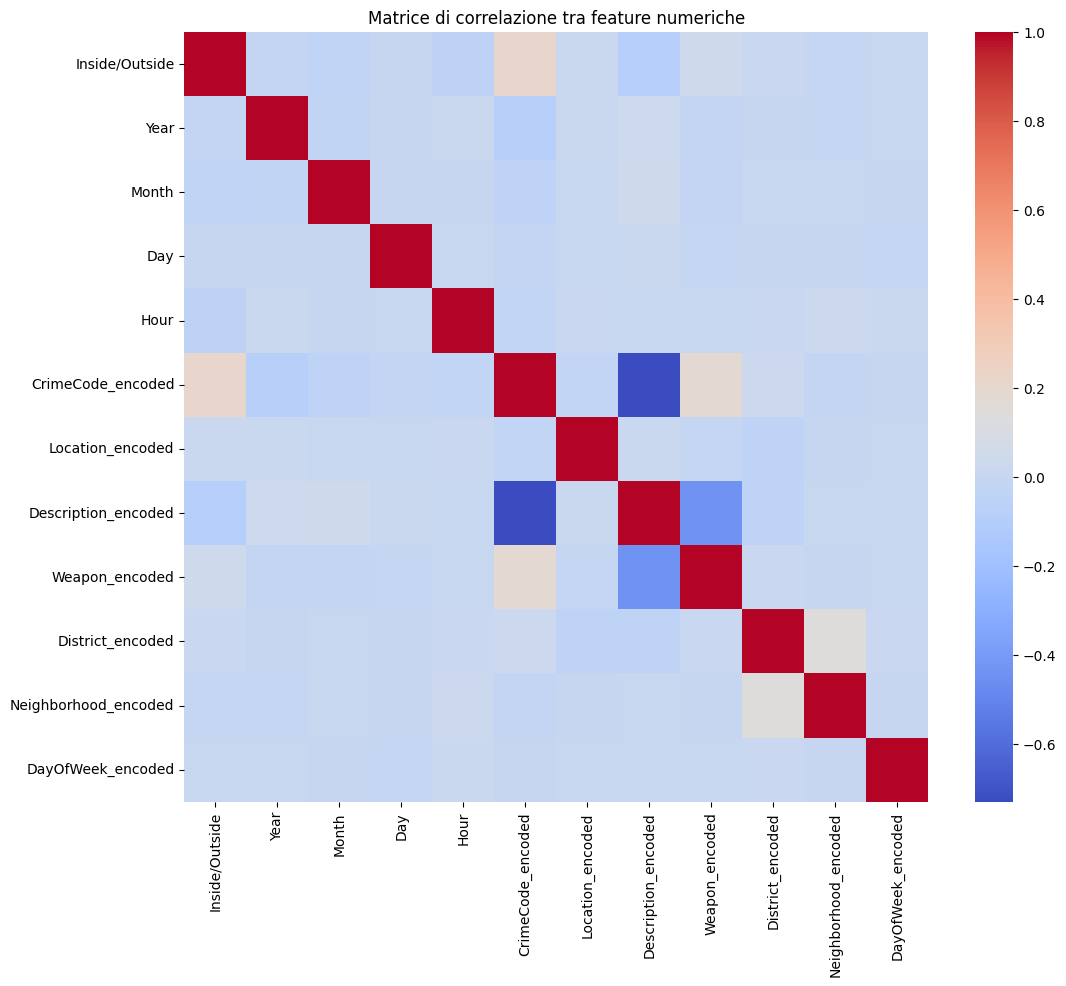

Coppie di feature fortemente correlate:
 CrimeCode_encoded    Description_encoded   -0.729184
Description_encoded  CrimeCode_encoded     -0.729184
dtype: float64


In [37]:
corr_matrix = crime_data_weapon.corr(numeric_only=True)

# Visualizzazione come heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Matrice di correlazione tra feature numeriche")
plt.show()

# Estrai tutte le coppie di correlazioni
corr_pairs = corr_matrix.unstack()

# Filtra le coppie fortemente correlate (escludendo la diagonale 1.0)
high_corr = corr_pairs[(abs(corr_pairs) > 0.7) & (abs(corr_pairs) < 1)]

# Ordina per valore di correlazione
high_corr = high_corr.sort_values(ascending=False)

if high_corr.size == 0:
    print("Non ci sono coppie di feature altamente correlate")
else:
    print("Coppie di feature fortemente correlate:\n", high_corr)

Si decide di **eliminare** la feature `CrimeCode_encoded` in quanto risulta fortemente correlata con la feature `Description_encoded`.
Inoltre, dal momento che quest'ultima ha una discreta correlazione con la variabile target `Weapon_encoded`, risulta conveniente eliminarne almeno una, al fine di non **influenzare** la classificazione finale.

Si procede con la suddivisione del dataset finale in training (80%) e test (20%).

In [38]:
# Eliminazione delle feature fortemente correlate
crime_data_weapon = crime_data_weapon.drop(columns=['CrimeCode_encoded'])

X = crime_data_weapon.drop('Weapon_encoded', axis=1)
y = crime_data_weapon['Weapon_encoded']

# Split del dataset in train e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Controllo della distribuzione delle classi
print("Distribuzione delle classi nel dataset di training:")
print(y_train.value_counts(normalize=True)*100)
print("Numero di elementi per ogni classe nel dataset di training:")
print(y_train.value_counts())

print("\nDistribuzione delle classi nel dataset di test:")
print(y_test.value_counts(normalize=True)*100)
print("Numero di elementi per ogni classe nel dataset di test:")
print(y_test.value_counts())


Distribuzione delle classi nel dataset di training:
Weapon_encoded
1    55.472387
0    18.494373
3    15.480167
2    10.553074
Name: proportion, dtype: float64
Numero di elementi per ogni classe nel dataset di training:
Weapon_encoded
1    41353
0    13787
3    11540
2     7867
Name: count, dtype: int64

Distribuzione delle classi nel dataset di test:
Weapon_encoded
1    55.470301
0    18.495466
3    15.479959
2    10.554274
Name: proportion, dtype: float64
Numero di elementi per ogni classe nel dataset di test:
Weapon_encoded
1    10338
0     3447
3     2885
2     1967
Name: count, dtype: int64


Seppure le classi risultino **sbilanciate**, proviamo ad effettuare le predizioni mantenendo questa distribuzione di valori, per vedere come i vari modelli si comportano.

Definiamo i classificatori utilizzati per la predizione dell'arma usata. Le tecniche impiegate sono le seguenti:
- **Decision Tree**
- **Random Forest**
- **Ada Boost Classifier**
- **Gradient Boost Classifier**
- **Rete neurale MLP**

In [ ]:
# ==============================
# Definizione dei classificatori
# ==============================
classifiers = [
    ("DecisionTreeClassifier", DecisionTreeClassifier(random_state=42), {"max_depth": [10,13,15,18, 20, 23]}),
    ("RandomForestClassifier", RandomForestClassifier(random_state=42), {"n_estimators": [5,10,15, 25, 30], "max_depth": [10,13,15,18, 20, 23]}),
    ("AdaBoostClassifier", AdaBoostClassifier(random_state=42), {"n_estimators": [5,10,15, 25, 30]}),
    ("GradientBoostingClassifier", GradientBoostingClassifier(random_state=42), {"n_estimators": [5,15,25, 25, 30]}),
    ("NeuralNetwork", Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(64, 32, 16), 
            activation='relu',
            solver='adam',
            max_iter=100,
            random_state=42
        ))
    ]), {"clf__hidden_layer_sizes": [(64,32,16),(32,16,8)], "clf__max_iter": [300,400]})
]

def train_and_evaluate_models(classifiers, X_train, y_train, X_test, y_test):
    """
    Esegue addestramento e GridSearch per ogni classificatore,
    salvando modelli, metriche, confusion matrix e probabilità.
    """
    results = {}

    for name, model, param_grid in classifiers:
        print(f"\n🔹 Addestramento e ricerca iperparametri per {name}...")

        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=4,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)

        # Calcolo probabilità se disponibile
        y_proba = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None

        results[name] = {
            'best_model': best_model,
            'best_params': grid.best_params_,
            'accuracy': best_model.score(X_test, y_test),
            'report': report,
            'confusion_matrix': cm,
            'y_pred': y_pred,
            'y_proba': y_proba
        }

    return results   

def summarize_metrics(results):
    """
    Crea un DataFrame con le principali metriche per ogni modello.
    """
    metrics_summary = pd.DataFrame([
        {
            "Modello": name,
            "Accuracy": res['accuracy'],
            "Precision (macro)": res['report']['macro avg']['precision'],
            "Recall (macro)": res['report']['macro avg']['recall'],
            "F1-score (macro)": res['report']['macro avg']['f1-score']
        }
        for name, res in results.items()
    ])

    print("\n📊 CONFRONTO FINALE DELLE METRICHE:\n")
    print(metrics_summary.to_string(index=False))
    return metrics_summary

def plot_accuracy_bar(metrics_summary):
    """
    Crea un grafico a barre per l'Accuracy
    """
    plt.figure(figsize=(8, 5))
    plt.bar(metrics_summary["Modello"], metrics_summary["Accuracy"], color='skyblue')
    plt.title("Confronto Accuracy tra Classificatori")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(results, cols=3):
    """
    Crea un grafico con le matrici di confusione in un unico grafico
    """
    num_models = len(results)
    rows = int(np.ceil(num_models / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    for ax, (name, res) in zip(axes, results.items()):
        disp = ConfusionMatrixDisplay(res['confusion_matrix'])
        disp.plot(cmap='Blues', ax=ax, colorbar=False)
        ax.set_title(name, fontsize=12)
        ax.grid(False)

    # Rimuove assi vuoti
    for j in range(len(results), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Confronto Matrici di Confusione", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_roc_curves(results, y_test, cols=3):
    """
    Crea un grafico con le curve ROC per ogni classe
    """
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    num_models = len(results)
    rows = int(np.ceil(num_models / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
    axes = axes.flatten()

    for ax, (name, res) in zip(axes, results.items()):
        if res['y_proba'] is not None:
            y_proba = res['y_proba']
            for i, c in enumerate(classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, label=f"Classe {c} (AUC={roc_auc:.2f})")

            ax.plot([0, 1], [0, 1], 'k--', alpha=0.6)
            ax.set_title(name, fontsize=12)
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.legend(loc="lower right", fontsize=8)
            ax.grid(True, linestyle='--', alpha=0.4)
        else:
            ax.set_visible(False)

    # Rimuove assi vuoti
    for j in range(len(results), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("ROC Multiclasse – Confronto tra Modelli", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
def plot_neural_network_loss(results):
    """
    Crea un grafico per la Loss della rete neurale (versione robusta).
    Gestisce sia le pipeline semplici (clf) che quelle annidate (model__clf).
    """
    if "NeuralNetwork" not in results:
        return

    best_model = results["NeuralNetwork"]["best_model"]
    clf = None

    try:
        clf = best_model.named_steps['model'].named_steps['clf']
        
    except KeyError:
        try:
            clf = best_model.named_steps['clf']
            
        except KeyError:
            print("\n--- ERRORE DEBUG: plot_neural_network_loss ---")
            print("Impossibile trovare lo step 'clf' o 'model'->'clf'.")
            print("La pipeline 'best_model' per NeuralNetwork ha i seguenti steps:")
            print(best_model.named_steps.keys())
            print("--------------------------------------------------\n")
            return

    if clf and hasattr(clf, "loss_curve_"):
        plt.figure(figsize=(6, 4))
        plt.plot(clf.loss_curve_)
        plt.title("Rete neurale - Andamento del Loss")
        plt.xlabel("Epoca")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    elif clf:
        print("Trovato il classificatore, ma l'attributo 'loss_curve_' non è disponibile.")


🔹 Addestramento e ricerca iperparametri per DecisionTreeClassifier...

🔹 Addestramento e ricerca iperparametri per RandomForestClassifier...

🔹 Addestramento e ricerca iperparametri per AdaBoostClassifier...


C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



🔹 Addestramento e ricerca iperparametri per GradientBoostingClassifier...

🔹 Addestramento e ricerca iperparametri per NeuralNetwork...

📊 CONFRONTO FINALE DELLE METRICHE:

                   Modello  Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
    DecisionTreeClassifier  0.773139           0.613429        0.622861          0.602140
    RandomForestClassifier  0.796480           0.656604        0.662999          0.651591
        AdaBoostClassifier  0.673553           0.539795        0.488317          0.394590
GradientBoostingClassifier  0.776573           0.606109        0.621335          0.565039
             NeuralNetwork  0.775500           0.614702        0.625977          0.601244


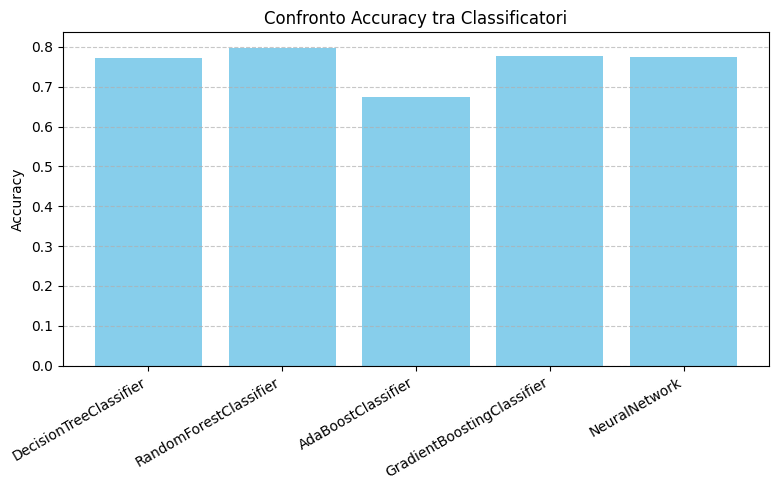

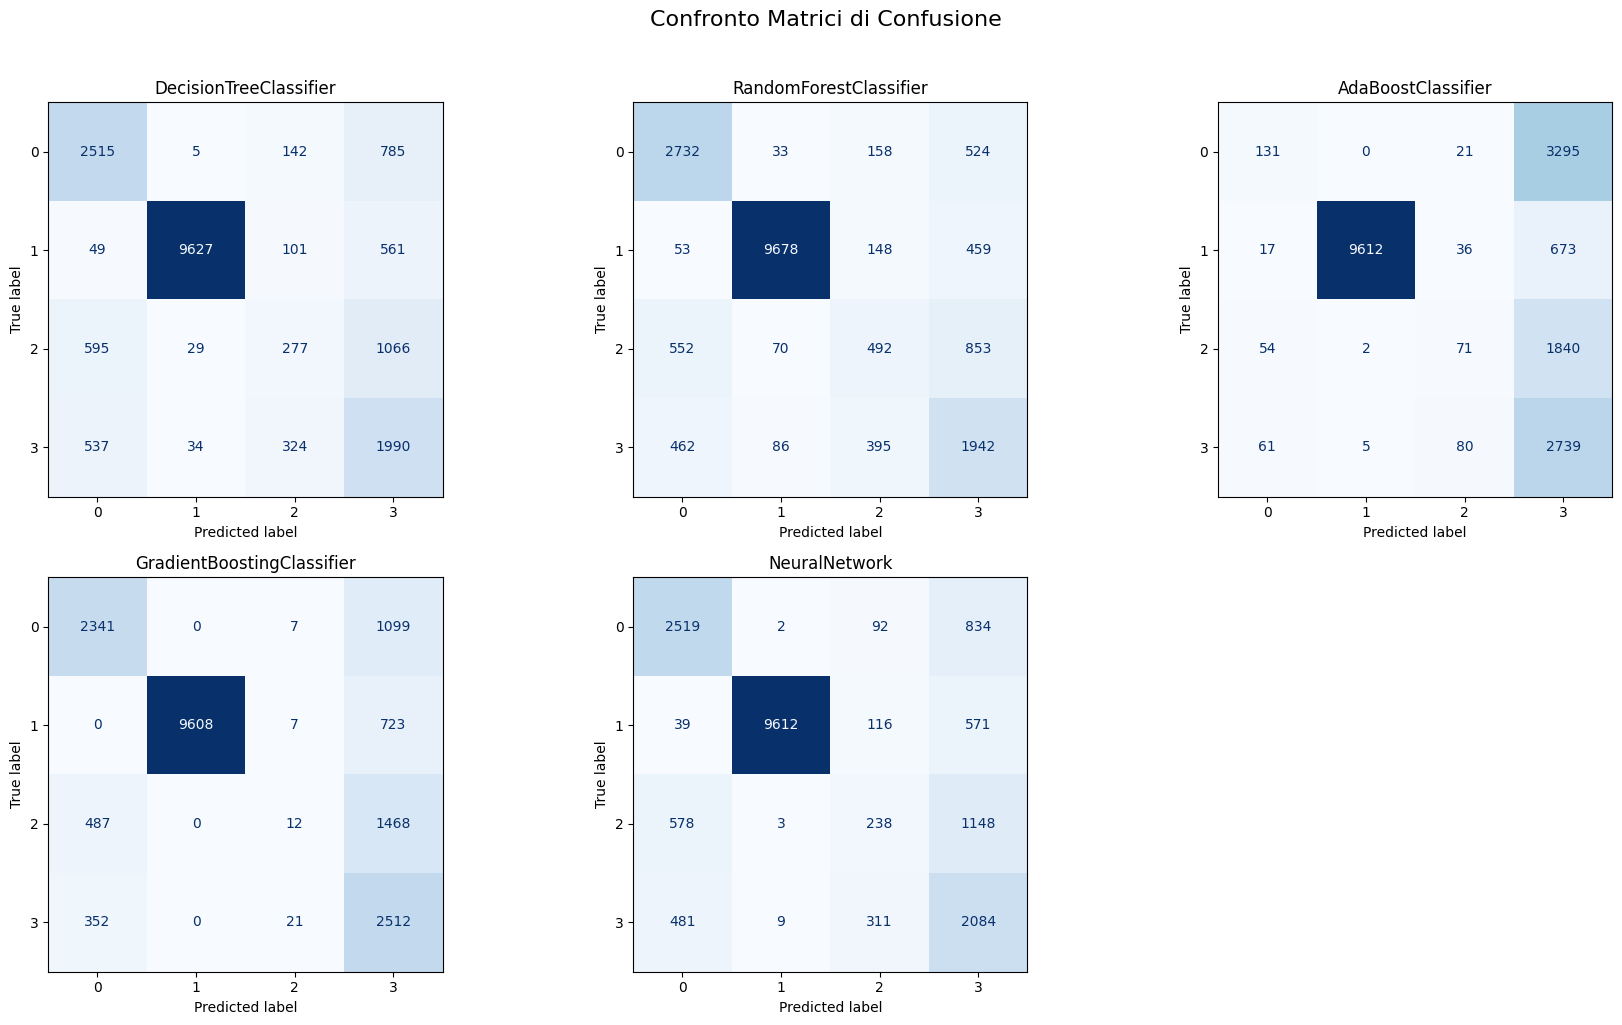

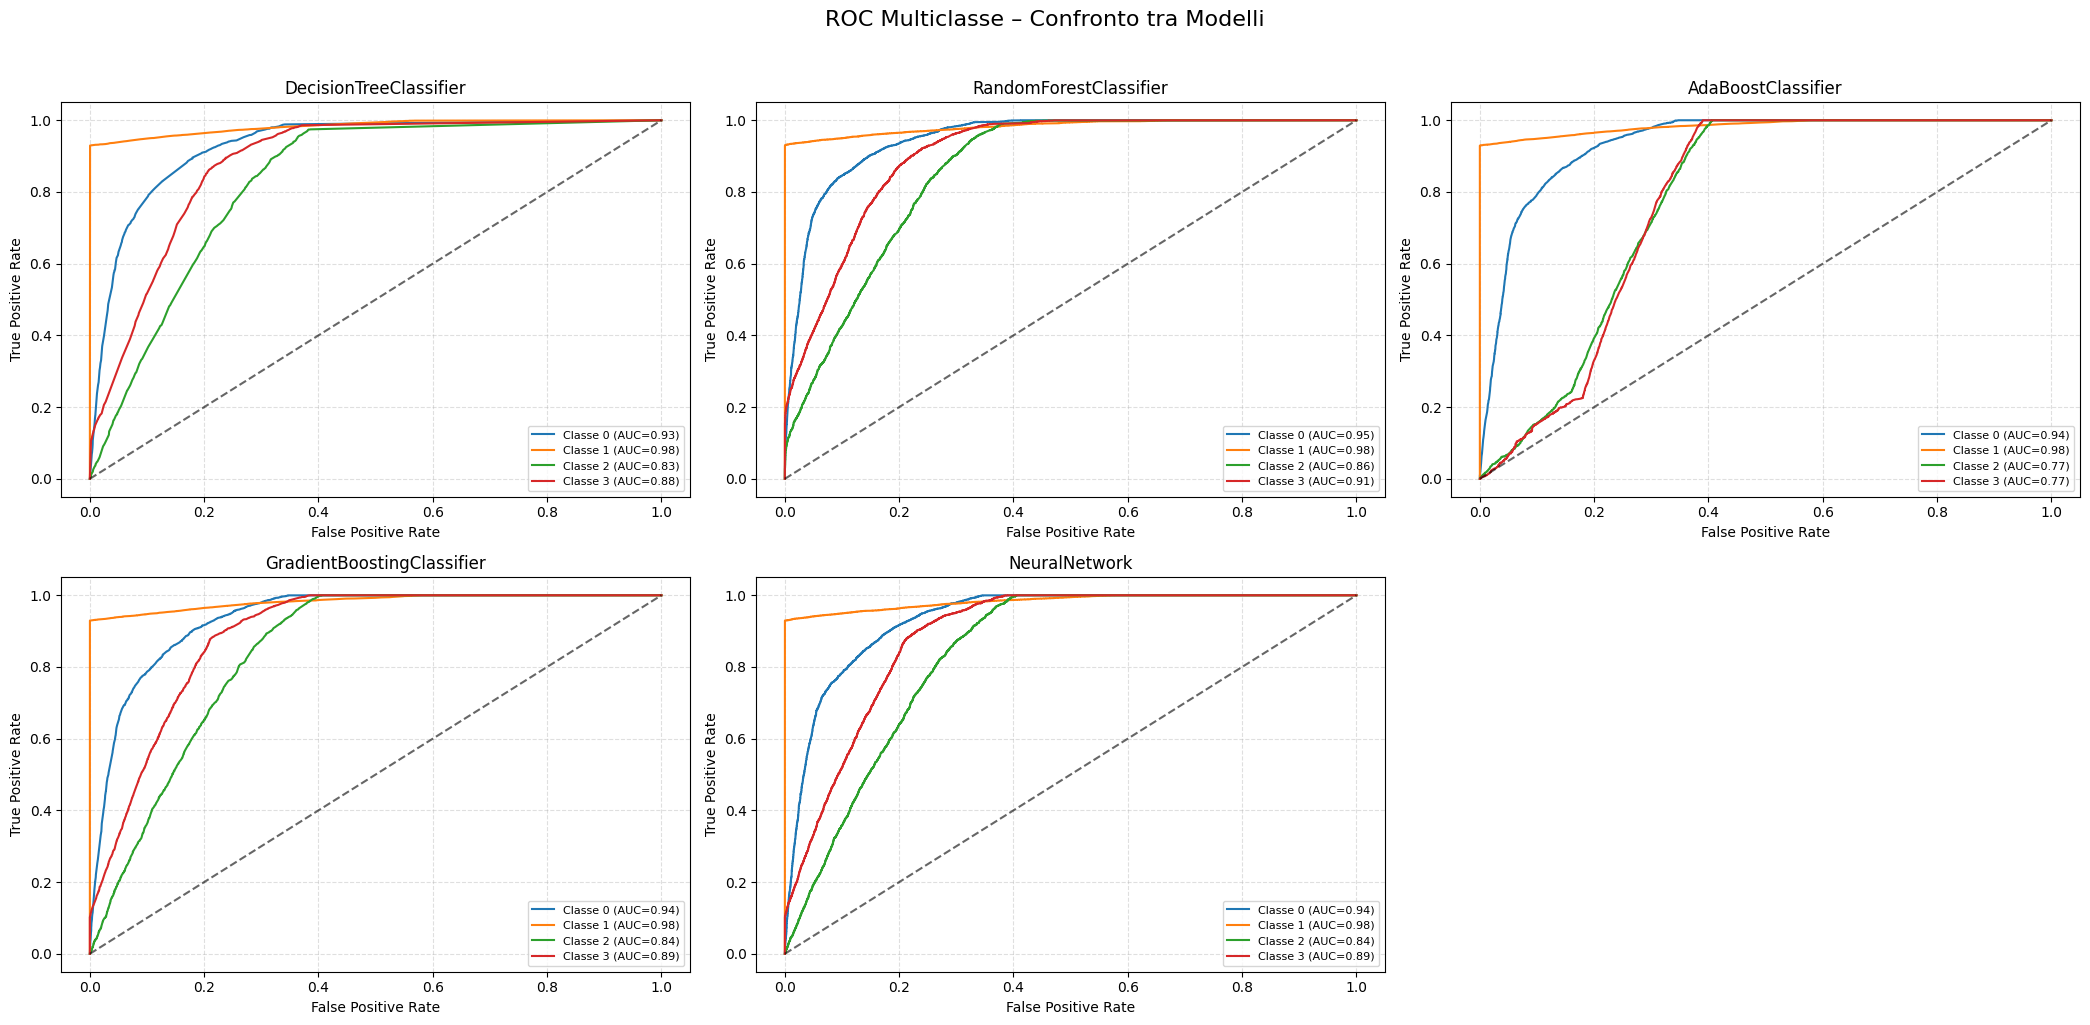

Trovata struttura pipeline semplice.


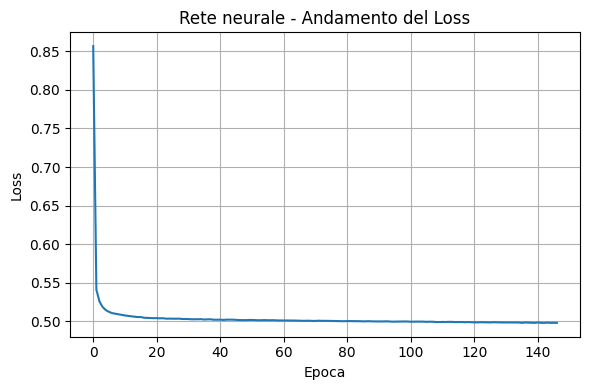

In [43]:
# Addestramento e ricerca iperparametri per ogni classificatore
results = train_and_evaluate_models(classifiers, X_train, y_train, X_test, y_test)

# Visualizzazione dei risultati
metrics_summary = summarize_metrics(results)
plot_accuracy_bar(metrics_summary)
plot_confusion_matrices(results)
plot_roc_curves(results, y_test)
plot_neural_network_loss(results)

Il confronto delle metriche aggregate (tabella e primo grafico a barre) fornisce una visione d'insieme chiara:
- Il modello migliore risulta essere **Random Forest**, che supera tutti gli altri in ogni metrica chiave.
- Seguono **GradientBoosting**, **NeuralNetwork**, **DecisionTree**, che si comportano in modo molto simile, con prestazioni comunque buone.
- Il modello **AdaBoostClassifier** ha prestazioni decisamente inferiori, con F1-Score particolarmente basso, indicando che fa molta fatica a bilanciare Precision e Recall.

Analizzando le matrici di confusione, emergono le sfide più interessanti: il problema principale è il **forte squilibrio delle classi**.
Questo si può capire anche dal confronto tra Accuracy e F1-Score, dove l'Accuracy è alta (quasi `80%`), con l'F1-Score solo del `65%`. Questa discrepanza suggerisce che l'Accuracy è "gonfiata" dalla capacità del modello di **indovinare correttamente la classe maggioritaria**.
Infatti, osservando le matrici di confusione, si può notare come **tutti i modelli sono eccellenti nel predire la Classe 1**.
Le **Classi 0 e 2** vengono spesso confuse e erroneamente classificate come **Classe 3**, mentre i risultati del modello AdaBoost è visibile anche nella sua matrice di confusione, spiegando le metriche peggiori.

Le curve ROC, infine, mostrano l'abilità del modello di distinguere tra le classi.
- La **performance è buona**: le aree sotto la curva (AUC) sono molto alte per quasi tutti i modelli (escluso AdaBoost).
- Il **controsenso apparente**: un AUC alto significa che il modello assegna probabilità "corrette" (ad esempio un campione di Classe 0 ha una probabilità più alta di essere Classe 0 che di essere Classe 3). Tuttavia, quando si passa dalle probabilità alla classificazione finale, il modello "sceglie" la classe che massimmizza la probabilità. A causa dello squilibrio, il modello si "sbilancia" preferendo la Classe 3 (o la 1) anche quando la probabilità per la Classe 0 o 2 è discreta. In breve, i modello **sanno distinguere le classi** (alto AUC), ma **fanno la scelta sbagliata** al momento della classificazione finale a causa dello squilibrio dei dati.

Per quanto riguarda l'andamento della Loss della **Rete Neurale**, si può notare che:
- **Convergenza rapida**: l'errore scende verticalmente nelle prime 10-20 epoche, per poi stabilizzarsi intorno ad un valore di `0.50`.
- **Stabilità**: la curva si appiattisce e rimane bassa, indicando che il modello ha trovato una soluzione stabile e non sta "oscillando" o peggiorando (quindi overfitting) nelle epoche successive.

In conclusione, il vero problema del dataset è quindi l'**impatto dello squilibrio delle classi**. L'accuracy è alta, ma le prestazioni sulle classi minoritarie (0,2,3) sono scarse.

### **Classificazione con SMOTEENN**

Dal momento che le predizioni risultano discrete per la classe maggioritaria 1 ('HANDS'), ma piuttosto povere per le restanti classi, si tenta l'implementazione di una tecnica ibrida **Upsampling + Downsampling**: si intende aumentare artificialmente il numero di campioni presenti nel dataset di training, inerenti alle classi 0 (`FIREARM`), 2 (`KNIFE`) e 3 (`OTHER`) ed effettuarne poi una pulizia.

Si utilizzerà la tecnica **SMOTE+ENN** sul training set per creare "nuovi" campioni delle cassi minoritarie. Usando una `PipeLine` viene assicurato che il ricampionamento avvenga solo sul set di addestramento all'interno di ogni singolo fold della cross-validation, evitando di "contaminare" i dati di validazione.


🔹 Addestramento e ricerca iperparametri per DecisionTreeClassifier...

🔹 Addestramento e ricerca iperparametri per RandomForestClassifier...

🔹 Addestramento e ricerca iperparametri per AdaBoostClassifier...


C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\matte\AppData\Roaming\Python\Python312\site-pac


🔹 Addestramento e ricerca iperparametri per GradientBoostingClassifier...

🔹 Addestramento e ricerca iperparametri per NeuralNetwork...

📊 CONFRONTO FINALE DELLE METRICHE:

                   Modello  Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
    DecisionTreeClassifier  0.760101           0.612964        0.622966          0.616309
    RandomForestClassifier  0.778505           0.637998        0.651450          0.643351
        AdaBoostClassifier  0.773408           0.536849        0.615799          0.557943
GradientBoostingClassifier  0.763320           0.620613        0.628357          0.622300
             NeuralNetwork  0.760852           0.612404        0.624727          0.616386


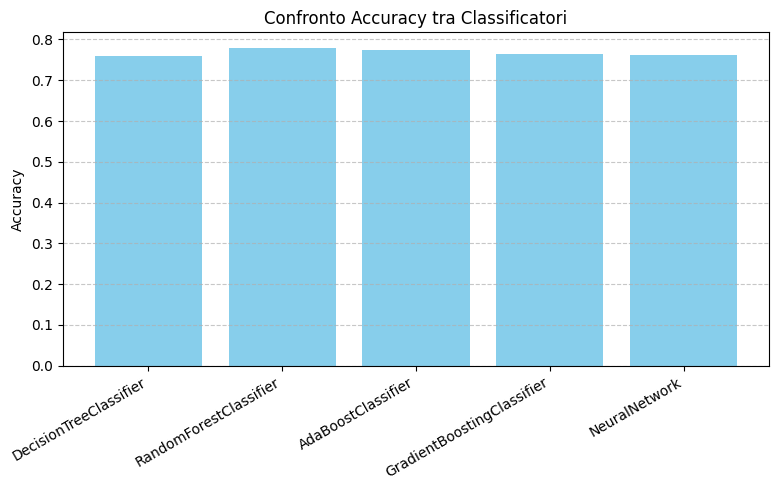

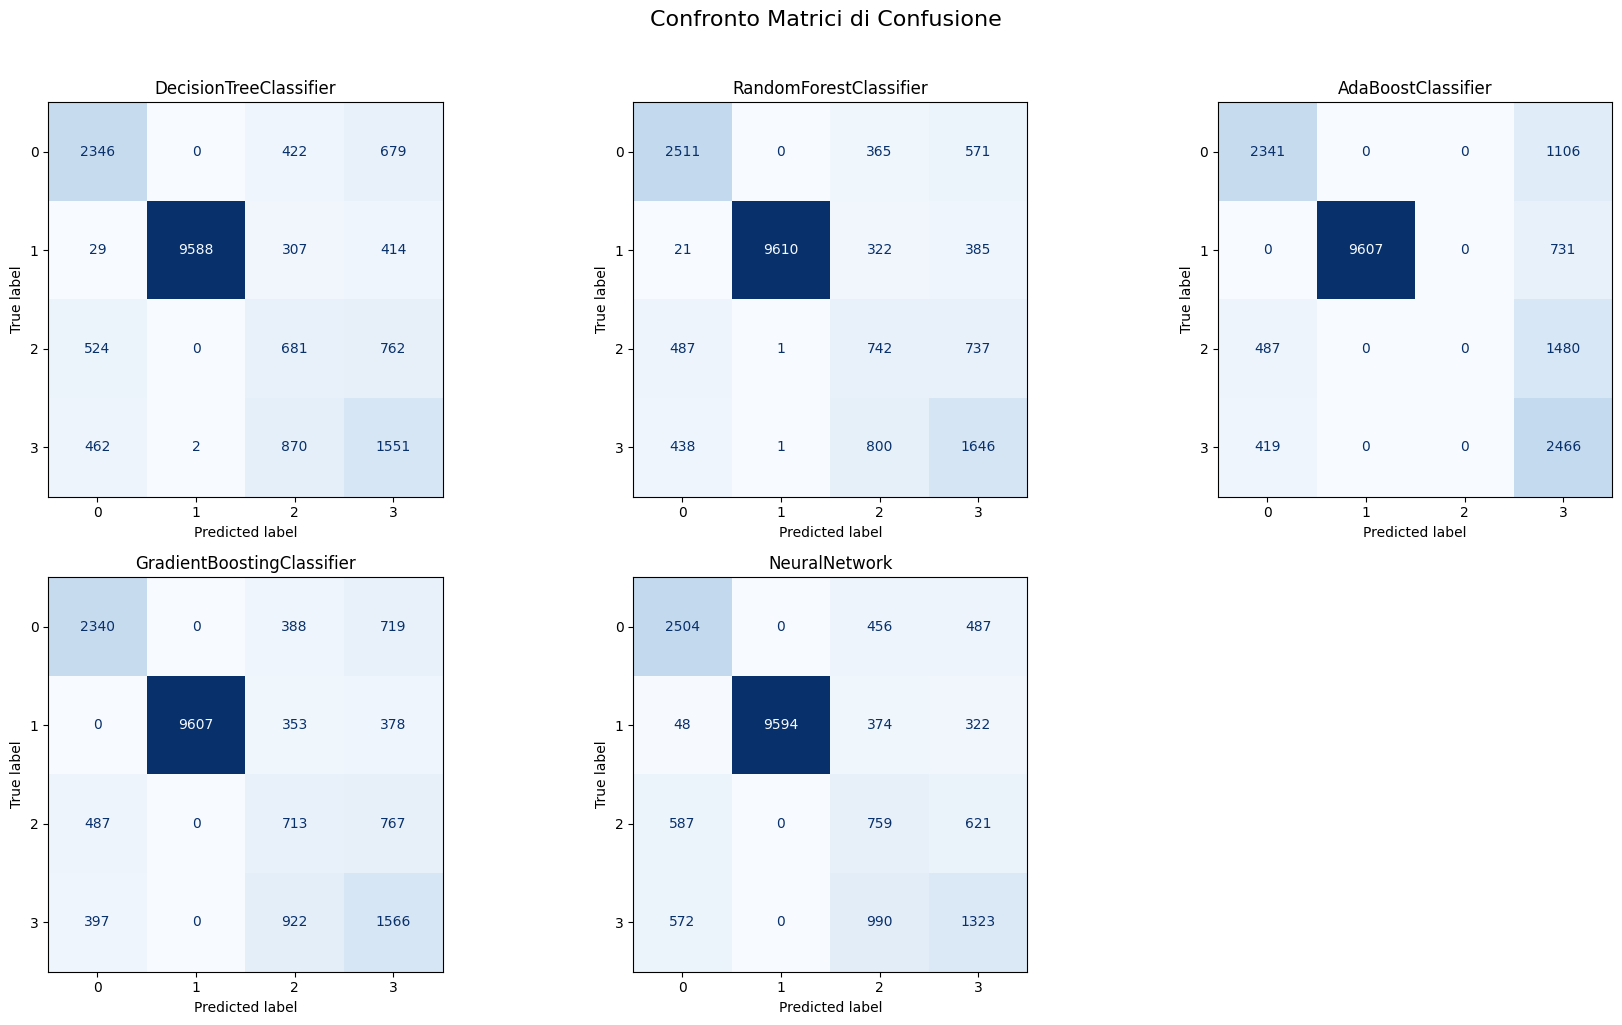

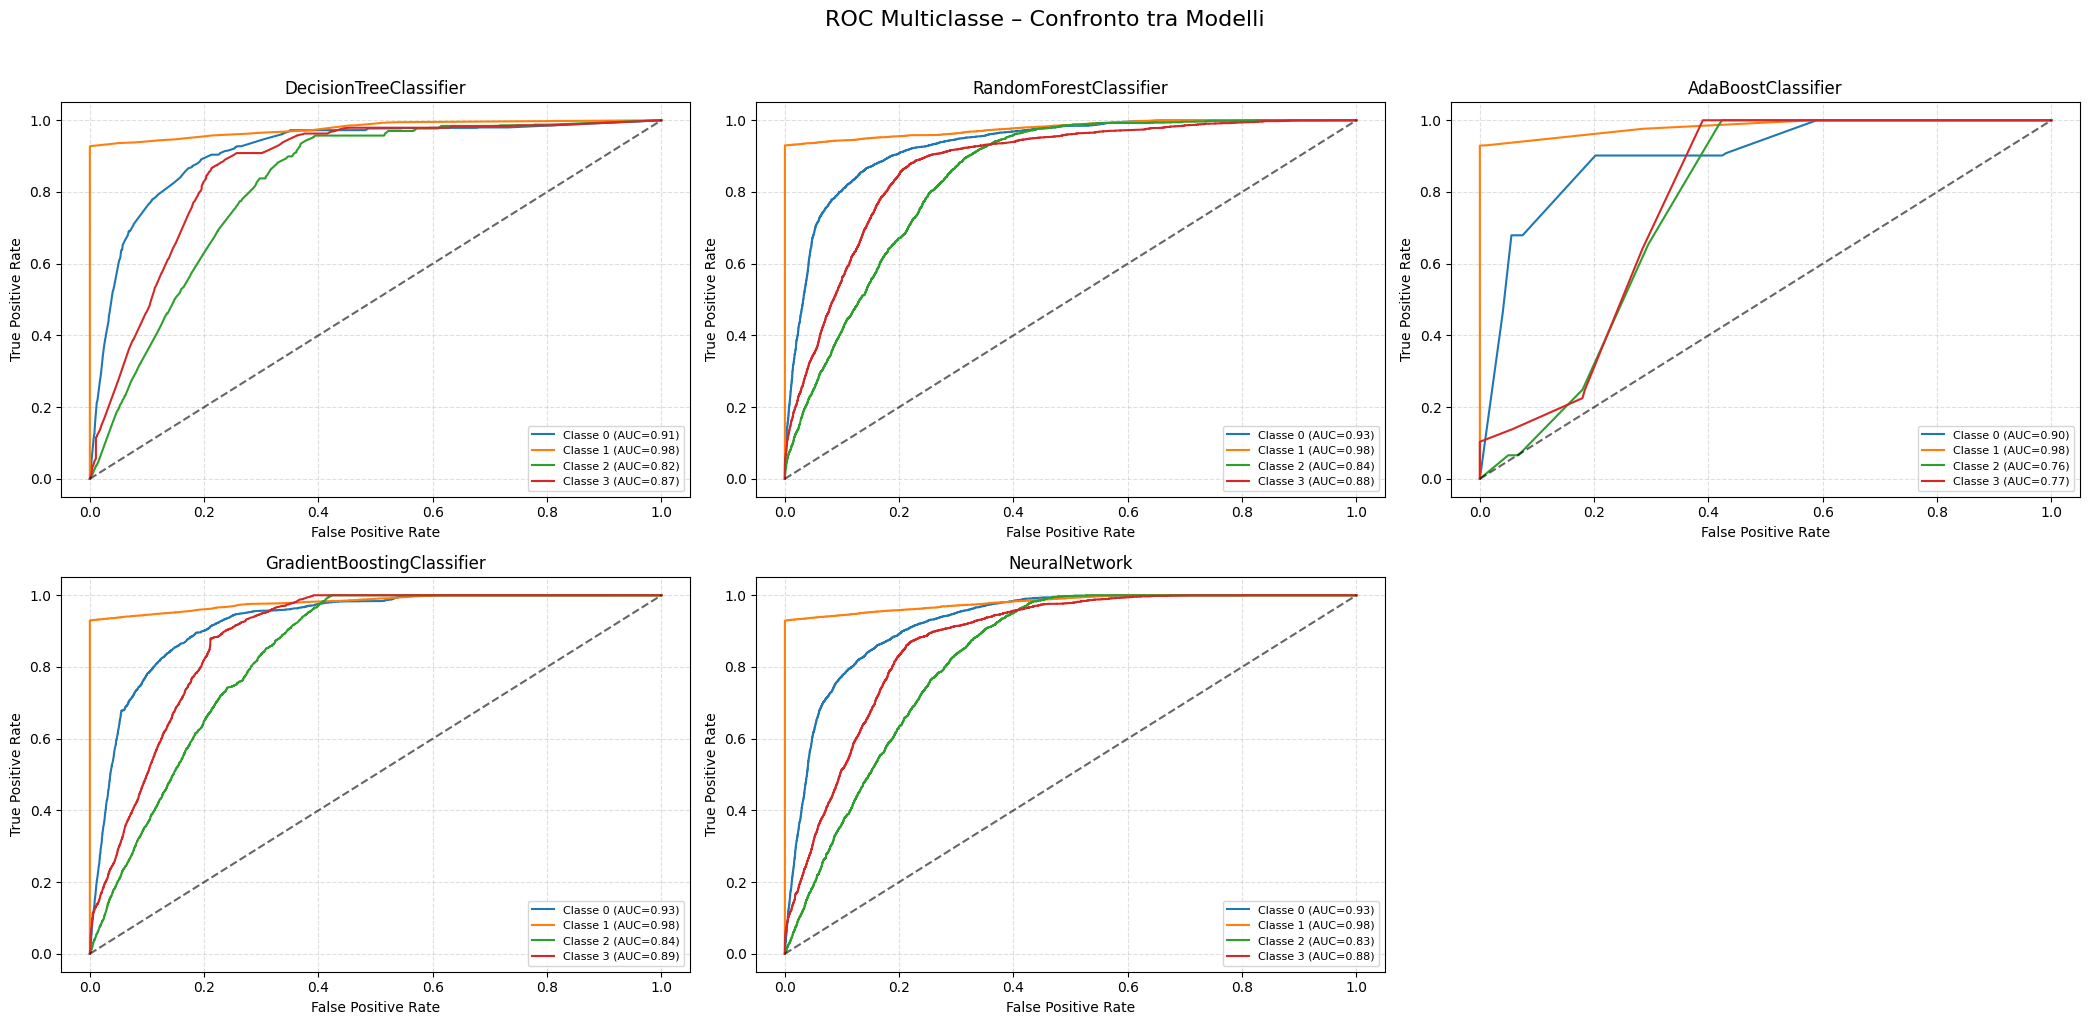

Trovata struttura pipeline annidata (SMOTEENN).


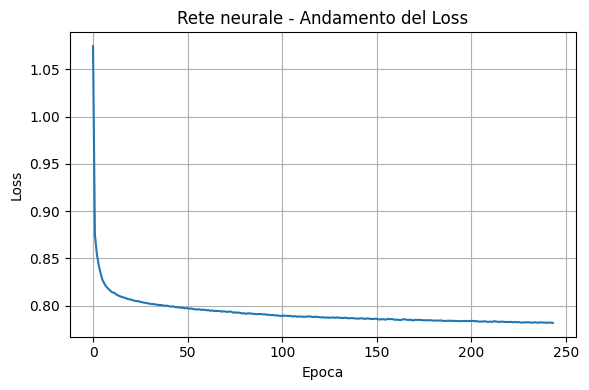

In [44]:
# ==============================
# Definizione dei classificatori CON BILANCIAMENTO
# ==============================

classifiers_smoteenn = [
    ("DecisionTreeClassifier",
     ImbPipeline([
         ('resampling', SMOTEENN(random_state=42)),
         ('model', DecisionTreeClassifier(random_state=42))
     ]),
     {"model__max_depth": [10, 13, 15, 18, 20, 23]}),

    ("RandomForestClassifier",
     ImbPipeline([
         ('resampling', SMOTEENN(random_state=42)),
         ('model', RandomForestClassifier(random_state=42))
     ]),
     {"model__n_estimators": [5, 10, 15, 25, 30], "model__max_depth": [10, 13, 15, 18, 20, 23]}),

    ("AdaBoostClassifier",
     ImbPipeline([
         ('resampling', SMOTEENN(random_state=42)),
         ('model', AdaBoostClassifier(random_state=42))
     ]),
     {"model__n_estimators": [5, 10, 15, 25, 30]}),

    ("GradientBoostingClassifier",
     ImbPipeline([
         ('resampling', SMOTEENN(random_state=42)),
         ('model', GradientBoostingClassifier(random_state=42))
     ]),
     {"model__n_estimators": [5, 15, 25, 25, 30]}),

    ("NeuralNetwork",
     ImbPipeline([
         ('resampling', SMOTEENN(random_state=42)),
         ('model', Pipeline([
             ('scaler', StandardScaler()),
             ('clf', MLPClassifier(
                 hidden_layer_sizes=(64, 32, 16),
                 activation='relu',
                 solver='adam',
                 max_iter=100,
                 random_state=42
             ))
         ]))
     ]),
     {"model__clf__hidden_layer_sizes": [(64, 32, 16), (32, 16, 8)],
      "model__clf__max_iter": [300, 400]})
]

# Addestramento e ricerca iperparametri per ogni classificatore
results_smoteenn = train_and_evaluate_models(classifiers_smoteenn, X_train, y_train, X_test, y_test)

# Visualizzazione dei risultati
metrics_summary_smoteenn = summarize_metrics(results_smoteenn)
plot_accuracy_bar(metrics_summary_smoteenn)
plot_confusion_matrices(results_smoteenn)
plot_roc_curves(results_smoteenn, y_test)
plot_neural_network_loss(results_smoteenn)

I risultati applicando la tecnica SMOTEENN sono contrastanti.
- Ai modelli che prima erano disastrosi, ora:
   - **AdaBoost**: Accuracy è cresciuta (da `0.673)` a `0.773`) e F1-Score migliorato fino ad arrivare ad un modello competente (da `0.395` a `0.558`).
   - **GradientBoosting**: F1-Score migliorata (da `0.565)` a `0.662`).
   Analizzando la matrice di confusione, si può notare come prima indovinava solo `12` campioni della Classe 2, ora ne indovina ben `713`, anche se è costato un po' di performance sulla Classe 3.

- Ai modelli che prima erano buoni, ora:
   - **RandomForest**: F1-Score peggiorato da `0.652` a `0.643`, Accuracy da `0.796` a `0.779`. Quindi, qualsiasi tentativo di bilanciamento ha peggiorato le prestazioni.

Osservando le **Curve ROC**, si può notare che per quasi tutti i modelli, il valori di **AUC sono scesi** rispetto al primo esperimento. Questo significa che i dati sintetici di SMOTE hanno reso i confini tra le classi più "confusi", rendendo più difficile per i modelli distinguere le classi.

Anche la **Loss della rete neurale** ora parte molto più alta e si stabilizza più in alto (circa `0.78` contro `0.50`). Questo conferma che il nuovo dataset "ricampionato" è più rumoroso e più difficile da imparare per il modello.

In breve, **ha salvato i modello peggiori, ma ha danneggiato i modelli migliori**. Il modello migliore risulta essere il **RandomForest originale**, ottenendo valori di metriche più alti.